In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df= np.random.seed(42)

customers = pd.DataFrame({
"customer_id": range(1001,1101),
"city": np.random.choice(["Delhi", "Mumbai", "Chandigarh", "Pune"],100),
"signup_date": pd.date_range(start="2025-01-01", periods=100)
})

customers.head()


,customer_id,city,signup_date
0,1001,Chandigarh,2025-01-01
1,1002,Pune,2025-01-02
2,1003,Delhi,2025-01-03
3,1004,Chandigarh,2025-01-04
4,1005,Chandigarh,2025-01-05


In [11]:
products= pd.DataFrame({
    "product_id":[1,2,3,4,5],
    "product_name":["Laptop", "Phone", "Headphones", "Keyboard", "Monitor"],
    "category": ["Electronics"]*5,
    "price": [80000,50000,3000,2000,15000]
})

products.head()

,product_id,product_name,category,price
0,1,Laptop,Electronics,80000
1,2,Phone,Electronics,50000
2,3,Headphones,Electronics,3000
3,4,Keyboard,Electronics,2000
4,5,Monitor,Electronics,15000


In [14]:
orders= pd.DataFrame({
    "order_id": range(5001,5201),
    "customer_id": np.random.choice(customers.customer_id, 200),
    "product_id": np.random.choice(products.product_id, 200),
    "order_date": pd.date_range(start="2025-02-01", periods=200),
    "quantity": np.random.randint(1,4,200)
})
    

In [15]:
orders= orders.merge(products, on="product_id")
orders["revenue"]= orders["price"] * orders["quantity"]
orders.head()

,order_id,customer_id,product_id,order_date,quantity,product_name,category,price,revenue
0,5001,1054,5,2025-02-01,2,Monitor,Electronics,15000,30000
1,5002,1003,3,2025-02-02,3,Headphones,Electronics,3000,9000
2,5003,1016,1,2025-02-03,3,Laptop,Electronics,80000,240000
3,5004,1087,2,2025-02-04,3,Phone,Electronics,50000,150000
4,5005,1057,1,2025-02-05,3,Laptop,Electronics,80000,240000


In [17]:
customers.to_csv("data/customers.csv",index=False)
products.to_csv("data/products.csv",index=False)
orders.to_csv("data/orders.csv",index=False)

In [19]:
orders=pd.read_csv("data/orders.csv")
customers=pd.read_csv("data/customers.csv")

In [20]:
orders.head()


,order_id,customer_id,product_id,order_date,quantity,product_name,category,price,revenue
0,5001,1054,5,2025-02-01,2,Monitor,Electronics,15000,30000
1,5002,1003,3,2025-02-02,3,Headphones,Electronics,3000,9000
2,5003,1016,1,2025-02-03,3,Laptop,Electronics,80000,240000
3,5004,1087,2,2025-02-04,3,Phone,Electronics,50000,150000
4,5005,1057,1,2025-02-05,3,Laptop,Electronics,80000,240000


In [21]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      200 non-null    int64 
 1   customer_id   200 non-null    int64 
 2   product_id    200 non-null    int64 
 3   order_date    200 non-null    object
 4   quantity      200 non-null    int64 
 5   product_name  200 non-null    object
 6   category      200 non-null    object
 7   price         200 non-null    int64 
 8   revenue       200 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 14.2+ KB


In [22]:
orders.isnull().sum()

order_id        0
customer_id     0
product_id      0
order_date      0
quantity        0
product_name    0
category        0
price           0
revenue         0
dtype: int64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders= pd.read_csv("data/orders.csv")
customers=pd.read_csv("data/customers.csv")

In [3]:
orders["order_date"]= pd.to_datetime(orders["order_date"])

In [4]:
orders.dtypes

order_id                 int64
customer_id              int64
product_id               int64
order_date      datetime64[ns]
quantity                 int64
product_name            object
category                object
price                    int64
revenue                  int64
dtype: object

In [5]:
df=orders.merge(customers, on="customer_id")

In [6]:
df.head()

,order_id,customer_id,product_id,order_date,quantity,product_name,category,price,revenue,city,signup_date
0,5001,1054,5,2025-02-01,2,Monitor,Electronics,15000,30000,Pune,2025-02-23
1,5002,1003,3,2025-02-02,3,Headphones,Electronics,3000,9000,Delhi,2025-01-03
2,5003,1016,1,2025-02-03,3,Laptop,Electronics,80000,240000,Delhi,2025-01-16
3,5004,1087,2,2025-02-04,3,Phone,Electronics,50000,150000,Mumbai,2025-03-28
4,5005,1057,1,2025-02-05,3,Laptop,Electronics,80000,240000,Pune,2025-02-26


In [9]:
total_revenue=df["revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 12058000


In [10]:
revenue_product= df.groupby("product_name")["revenue"].sum().sort_values(ascending=False)
print(revenue_product)

product_name
Laptop        6960000
Phone         3350000
Monitor       1320000
Headphones     258000
Keyboard       170000
Name: revenue, dtype: int64


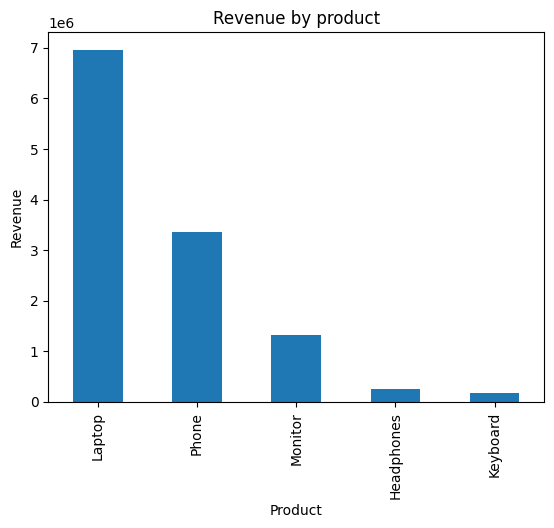

In [12]:
revenue_product.plot(kind="bar")
plt.title("Revenue by product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [15]:
revenue_city= df.groupby("city")["revenue"].sum().sort_values(ascending=False)
print(revenue_city)

city
Pune          4570000
Mumbai        3150000
Delhi         2602000
Chandigarh    1736000
Name: revenue, dtype: int64


In [16]:
top_customers= df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
print(top_customers)

customer_id
1092    529000
1075    489000
1021    445000
1082    410000
1023    394000
         ...  
1100      6000
1035      4000
1041      3000
1089      2000
1037      2000
Name: revenue, Length: 89, dtype: int64


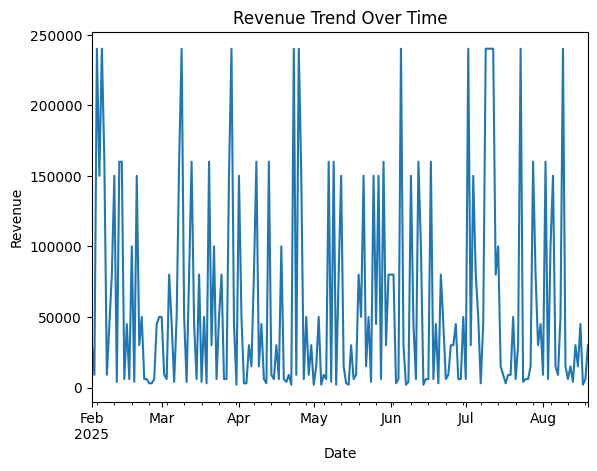

In [17]:
revenue_trend= df.groupby("order_date")["revenue"].sum()
revenue_trend.plot()

plt.title("Revenue Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [18]:
df.groupby("product_name")["revenue"].sum()

product_name
Headphones     258000
Keyboard       170000
Laptop        6960000
Monitor       1320000
Phone         3350000
Name: revenue, dtype: int64

In [19]:
first_purchase= df.groupby("customer_id")["order_date"].min()
first_purchase.head()

customer_id
1001   2025-04-09
1003   2025-02-02
1004   2025-05-04
1005   2025-03-21
1006   2025-03-12
Name: order_date, dtype: datetime64[ns]

In [20]:
df= df.merge(first_purchase, on="customer_id", suffixes=("","_first"))
df.head()


,order_id,customer_id,product_id,order_date,quantity,product_name,category,price,revenue,city,signup_date,order_date_first
0,5001,1054,5,2025-02-01,2,Monitor,Electronics,15000,30000,Pune,2025-02-23,2025-02-01
1,5002,1003,3,2025-02-02,3,Headphones,Electronics,3000,9000,Delhi,2025-01-03,2025-02-02
2,5003,1016,1,2025-02-03,3,Laptop,Electronics,80000,240000,Delhi,2025-01-16,2025-02-03
3,5004,1087,2,2025-02-04,3,Phone,Electronics,50000,150000,Mumbai,2025-03-28,2025-02-04
4,5005,1057,1,2025-02-05,3,Laptop,Electronics,80000,240000,Pune,2025-02-26,2025-02-05


In [22]:
df["cohort_month"]= df["order_date_first"].dt.to_period("M")


In [23]:
df["order_month"]= df["order_date"].dt.to_period("M")

In [24]:
df["cohort_index"]=(
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12+
    (df["order_month"].dt.month - df["cohort_month"].dt.month))

In [25]:
cohort_data = df.groupby(["cohort_month","cohort_index"])["customer_id"].nunique()
cohort_data= cohort_data.reset_index()
cohort_data.head()

,cohort_month,cohort_index,customer_id
0,2025-02,0,24
1,2025-02,1,2
2,2025-02,2,4
3,2025-02,3,7
4,2025-02,4,4


In [27]:
cohort_table = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

cohort_table

cohort_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2025-02,24.0,2.0,4.0,7.0,4.0,6.0,3.0
2025-03,27.0,9.0,8.0,8.0,8.0,4.0,NaN
2025-04,14.0,2.0,2.0,4.0,3.0,NaN,NaN
2025-05,10.0,3.0,4.0,1.0,NaN,NaN,NaN
2025-06,5.0,1.0,NaN,NaN,NaN,NaN,NaN
2025-07,5.0,1.0,NaN,NaN,NaN,NaN,NaN
2025-08,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
retention = cohort_table.divide(cohort_table.iloc[:,0], axis=0)
retention

cohort_index,0,1,2,3,4,5,6
cohort_month,,,,,,,
2025-02,1.0,0.083333,0.166667,0.291667,0.166667,0.250000,0.125
2025-03,1.0,0.333333,0.296296,0.296296,0.296296,0.148148,NaN
2025-04,1.0,0.142857,0.142857,0.285714,0.214286,NaN,NaN
2025-05,1.0,0.300000,0.400000,0.100000,NaN,NaN,NaN
2025-06,1.0,0.200000,NaN,NaN,NaN,NaN,NaN
2025-07,1.0,0.200000,NaN,NaN,NaN,NaN,NaN
2025-08,1.0,NaN,NaN,NaN,NaN,NaN,NaN


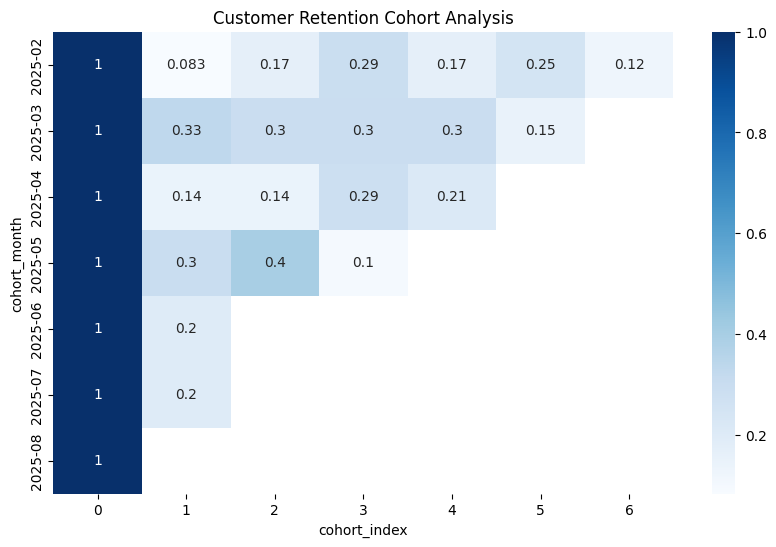

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(retention, annot=True, cmap="Blues")
plt.title("Customer Retention Cohort Analysis")
plt.show()

In [30]:
#clv=total revenue generated by each customer
clv= df.groupby("customer_id")["revenue"].sum()
clv.head()

customer_id
1001     51000
1003    139000
1004     91000
1005    216000
1006    133000
Name: revenue, dtype: int64

In [31]:
clv.mean()

np.float64(135483.14606741574)

In [32]:
clv= clv.reset_index()
clv.columns= ["customer_id", "customer_lifetime_value"]

clv.head()

,customer_id,customer_lifetime_value
0,1001,51000
1,1003,139000
2,1004,91000
3,1005,216000
4,1006,133000


In [33]:
top_clv= clv.sort_values("customer_lifetime_value", ascending=False).head(10)
top_clv

,customer_id,customer_lifetime_value
80,1092,529000
63,1075,489000
15,1021,445000
70,1082,410000
17,1023,394000
11,1016,393000
62,1074,344000
86,1098,330000
65,1077,324000
12,1017,321000


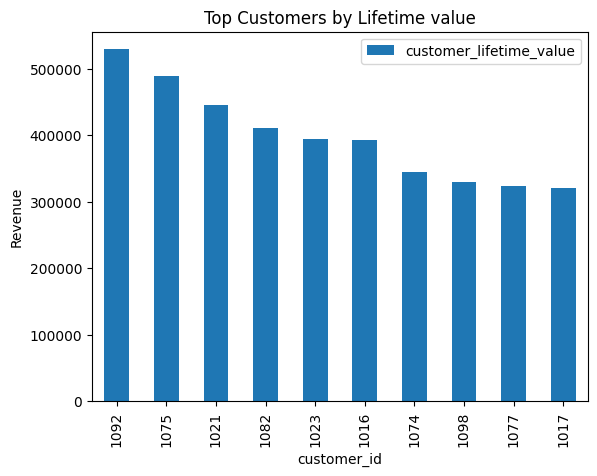

In [34]:
top_clv.plot(
    x="customer_id",
    y="customer_lifetime_value",
    kind="bar"
)

plt.title("Top Customers by Lifetime value")
plt.ylabel("Revenue")
plt.show()

In [36]:
last_purchase= df.groupby("customer_id")["order_date"].max()

In [38]:
last_purchase= last_purchase.reset_index()
last_purchase

,index,customer_id,order_date
0,0,1001,2025-08-11
1,1,1003,2025-05-16
2,2,1004,2025-07-20
3,3,1005,2025-08-12
4,4,1006,2025-07-06
...,...,...,...
84,84,1096,2025-07-24
85,85,1097,2025-06-18
86,86,1098,2025-06-15
87,87,1099,2025-04-08


In [45]:
today= df["order_date"].max()
last_purchase["days_since_last_purchase"] = (
    today - last_purchase["order_date"]
).dt.days

# Customer inactive for 60 days churn

In [40]:
last_purchase["churn"] = last_purchase["days_since_last_purchase"] > 60

In [43]:
churn_rate = last_purchase["churn"].mean()
print("Churn Rate:", churn_rate)

Churn Rate: 0.4606741573033708


In [44]:
print("Average CLV:", clv["customer_lifetime_value"].mean())
print("Churn Rate:", churn_rate)

Average CLV: 135483.14606741574
Churn Rate: 0.4606741573033708


In [46]:
final_df= df.merge(customers, on="customer_id")
final_df.head()

,order_id,customer_id,product_id,order_date,quantity,product_name,category,price,revenue,city_x,signup_date_x,order_date_first,cohort_month,order_month,cohort_index,city_y,signup_date_y
0,5001,1054,5,2025-02-01,2,Monitor,Electronics,15000,30000,Pune,2025-02-23,2025-02-01,2025-02,2025-02,0,Pune,2025-02-23
1,5002,1003,3,2025-02-02,3,Headphones,Electronics,3000,9000,Delhi,2025-01-03,2025-02-02,2025-02,2025-02,0,Delhi,2025-01-03
2,5003,1016,1,2025-02-03,3,Laptop,Electronics,80000,240000,Delhi,2025-01-16,2025-02-03,2025-02,2025-02,0,Delhi,2025-01-16
3,5004,1087,2,2025-02-04,3,Phone,Electronics,50000,150000,Mumbai,2025-03-28,2025-02-04,2025-02,2025-02,0,Mumbai,2025-03-28
4,5005,1057,1,2025-02-05,3,Laptop,Electronics,80000,240000,Pune,2025-02-26,2025-02-05,2025-02,2025-02,0,Pune,2025-02-26


In [48]:
final_df.to_csv("data/final_dataset.csv", index=False)